In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the purified data
df = pd.read_csv('../data/processed/cleaned_kidney_data.csv')

x = df.drop(['id', 'classification', 'ane', 'pe'], axis=1)
y = df['classification']

# 3. Splitting the data (80%, 20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

print("Data loaded and split! 'id', 'ane', and 'pe' have been successfully evicted.")

Data loaded and split! 'id', 'ane', and 'pe' have been successfully evicted.


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the Forest (100 Decision Trees)
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(x_train, y_train)

prediction = model.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test, prediction) * 100:.2f}%")

Accuracy Score: 100.00%


In [3]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Detailed Classification Report ---")
print(classification_report(y_test, prediction))

print("--- The Confusion Matrix ---")
print(confusion_matrix(y_test, prediction))

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

--- The Confusion Matrix ---
[[52  0]
 [ 0 28]]


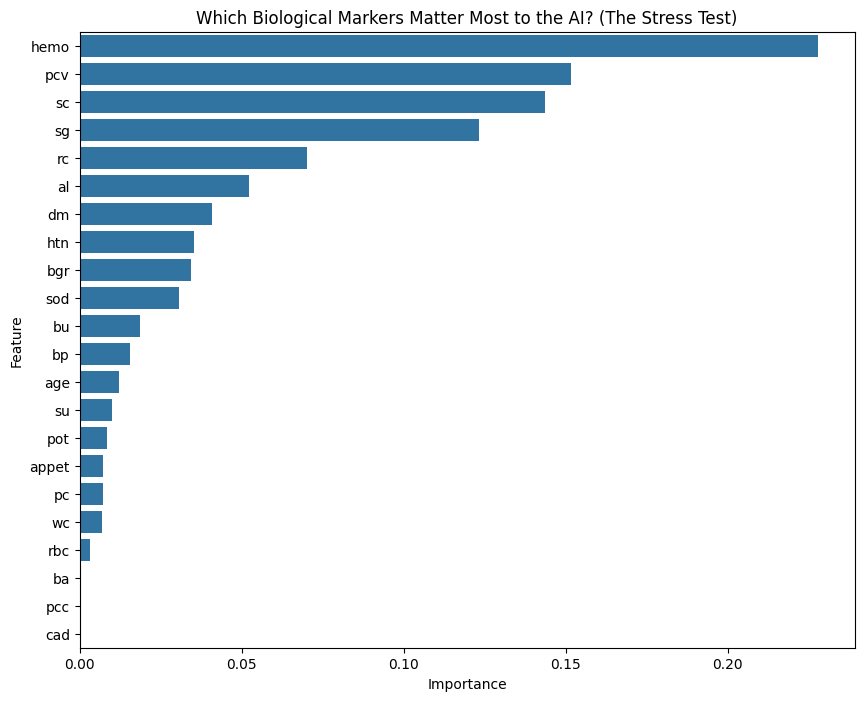

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extracting the Feature Importances
importances = model.feature_importances_
feature_names = x.columns

# 2. Organize them into a sorted table
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Visualize the "Biological Logic" of the AI
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Which Biological Markers Matter Most to the AI? (The Stress Test)')
plt.show()

CROSS-CHECKING THE MODEL

In [5]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x, y, cv=5)

print(f"Scroes for each of the 5 exams: {scores}")
print(f"Average True accuracy: {scores.mean() * 100:.2f}%")

Scroes for each of the 5 exams: [0.9875 1.     0.9625 0.9875 1.    ]
Average True accuracy: 98.75%


In [6]:
sample_patient = x_test.iloc[[5]]
actual_truth = y_test.iloc[5]

prediction = model.predict(sample_patient)[0]
confidence = model.predict_proba(sample_patient)[0]

print("--- Individual Patient X-Ray ---")
print(f"The Truth: Patient is Class {actual_truth} (0=Healthy, 2=CKD)")
print(f"AI Prediction: Class {prediction}")
print(f"AI Confidence: {confidence[0]*100:.1f}% sure it's Healthy, {confidence[1]*100:.1f}% sure it's CKD")

--- Individual Patient X-Ray ---
The Truth: Patient is Class 0 (0=Healthy, 2=CKD)
AI Prediction: Class 0
AI Confidence: 98.0% sure it's Healthy, 2.0% sure it's CKD


GRID SEARCH

In [9]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of parameters we want to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [None, 10, 20],         # How deep the trees can go
    'min_samples_split': [2, 5, 10],     # Minimum patients to split a branch
    'criterion': ['gini', 'entropy']     # The math used for the splits
}

# 2. Initialize the Grid Search
# 'cv=5' means it will do 5-fold cross-validation for every combination
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# 3. Start the search (this might take a minute)
grid_search.fit(x_train, y_train)

# 4. Results
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best F1-Score: {grid_search.best_score_ * 100:.2f}%")

# 5. Automatically use the best version for final predictions
best_model = grid_search.best_estimator_

Best Parameters found: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best F1-Score: 98.72%


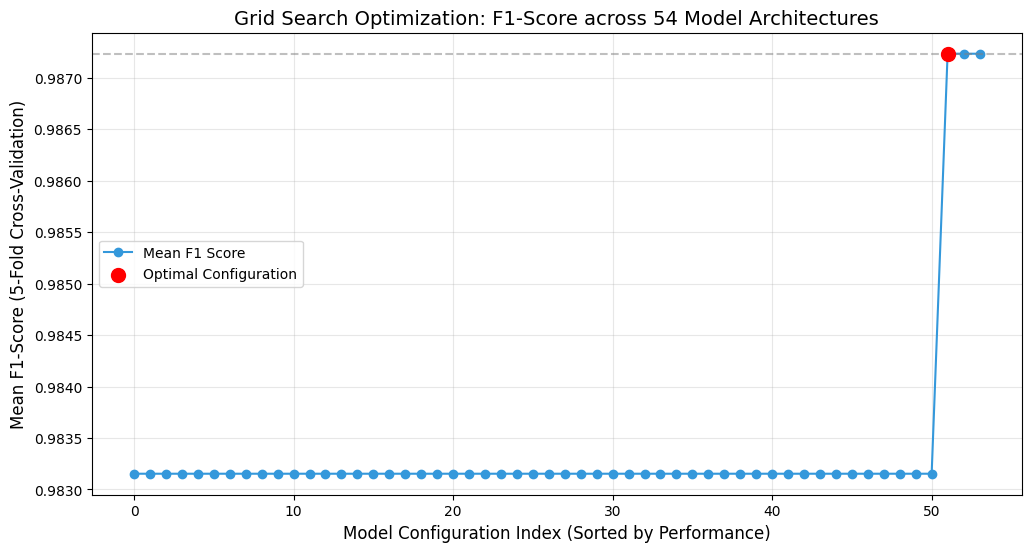

Graph generated: Optimization peak at 98.72%


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract the results from the grid search object
results = pd.DataFrame(grid_search.cv_results_)

# 2. Sort results to show a logical progression or just plot by index
results = results.sort_values(by='mean_test_score', ascending=True).reset_index()

# 3. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(results.index, results['mean_test_score'], marker='o', linestyle='-', color='#3498db', label='Mean F1 Score')

# 4. Highlight the "Peak" (The winning model)
best_idx = results['mean_test_score'].idxmax()
plt.scatter(best_idx, results.loc[best_idx, 'mean_test_score'], color='red', s=100, zorder=5, label='Optimal Configuration')

# 5. Formatting for the report
plt.title('Grid Search Optimization: F1-Score across 54 Model Architectures', fontsize=14)
plt.xlabel('Model Configuration Index (Sorted by Performance)', fontsize=12)
plt.ylabel('Mean F1-Score (5-Fold Cross-Validation)', fontsize=12)
plt.axhline(y=grid_search.best_score_, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

print(f"Graph generated: Optimization peak at {grid_search.best_score_*100:.2f}%")